In [1]:
#declaring the necessary librarys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.optimize import curve_fit

Part 1 of 8: Analytical solution for two boxes collisions ($M \geq m$)

We're told that the collisions are perfectly elastic. Therefore, total kinetic energy and total momentum are conserved at the collision. The conservation equations read:

$$ \frac{M V_b^2}{2} + \frac{m v_b^2}{2} = \frac{M V_a^2}{2} + \frac{m v_a^2}{2} $$

$$ M V_b + m v_b = M V_a + m v_a $$

We have to find and return the final velocities ($V_a, v_a$) and express the masses in terms of the given mass ratio $R = M/m$. Resulting in:

$$ V_a = \frac{R-1}{R+1}V_b + \frac{2}{R+1}v_b $$

$$ v_a = \frac{2R}{R+1}V_b + \frac{1-R}{R+1}v_b $$

we'll define the function as told on the pdf based on the resulting formula from above

In [2]:
def box_collision(Vb, vb, R):
 
    #using the velocities formula in expression of the given mass ratio
    Va = ((R - 1) / (R + 1)) * Vb + (2 / (R + 1)) * vb
    va = (2 * R / (R + 1)) * Vb + ((1 - R) / (R + 1)) * vb
    
    return Va, va

Part 2 of 8: Simulating the sequence of collisions

As told on thius exercise, the given assumptios lead to: $$ v_a = -v_b $$
Using this and the function from Part 1, we write NumberOfCollisions(Vi, R), which simulates the whole sequence of collisions. The function works as commented and returns the total number of collisions Nc and the list AllVelocities.

In [3]:
#defining the function  with the needed variables
def NumberOfCollisions(Vi, R):
    V, v = Vi, 0.0          
    Nc = 0                  
    AllVelocities = []      

    #looping due to the unknown number of colissions 
    while V > v:            
        #calling the previous function
        V, v = box_collision(V, v, R)
        Nc += 1
        AllVelocities.append([V, v])

        # if the small box moves right it hits the wall and reverses (collision effect)
        if v > 0:
            v = -v
            Nc += 1
            AllVelocities.append([V, v])

    #returnin total number of collisions and velocities listed
    return Nc, AllVelocities

To check that the function works, we test it for several mass ratios. For $R = 1$ we should expect 3 collisions (the boxes exchange velocities, the small box bounces off the wall and they collide once more), and for $R = 100$ we expect 31.

In [4]:
#loop for R with each inttended value
for R in [1, 2, 10, 100]:
    Nc, AllVelocities = NumberOfCollisions(1, R)
    print(f"R = {R:4}  ->  Nc = {Nc}")

R =    1  ->  Nc = 3
R =    2  ->  Nc = 5
R =   10  ->  Nc = 10
R =  100  ->  Nc = 31


Part 3 of 8: Does the number of collisions depend on the initial velocity?

For a fixed mass ratio $R = M/m$, we want to know if the total number of collisions $N_c$ depends on the initial velocity $V_i$. To find out, we keep $R = 100$ fixed and call NumberOfCollisions(Vi, R) for several very different values of $V_i$, and compare the results.

In [5]:
R = 100   # fixed mass ratio
Vi_values = [0.01, 0.1, 1, 10, 100, 1000]

#loop over the initial velocities, keeping R fixed
for Vi in Vi_values:
    Nc, AllVelocities = NumberOfCollisions(Vi, R)
    print(f"Vi = {Vi:8} m/s  ->  Nc = {Nc}")

Vi =     0.01 m/s  ->  Nc = 31
Vi =      0.1 m/s  ->  Nc = 31
Vi =        1 m/s  ->  Nc = 31
Vi =       10 m/s  ->  Nc = 31
Vi =      100 m/s  ->  Nc = 31
Vi =     1000 m/s  ->  Nc = 31


Observation: $N_c$ is exactly the same for all the values of $V_i$ we tried (for $R = 100$ it is always 31). The initial velocity does not affect the number of collisions.

Dimensional analysis shows that $N_c$ is a number and $R = M/m$ is dimensionless. The quantity $V_i$ has dimensions of velocity which's meters per second. The only other quantities in the problem are masses, measured in kilograms. There's no length or time scale present because the position of the wall doesn't matter. Without any quantity that has dimensions of length or time $V_i$ cannot be combined with anything to make a dimensionless number. Since $N_c$ must be dimensionless it can only depend on $R$. So $N_c$ is a function of $R$: $N_c = N_c(R)$. Changing $V_i$ just scales all velocities by the factor. The collision formulas are linear, in velocities. The sequence of collisions stays the same regardless of the initial speed.

Part 4 of 8: Geometrical view of the collisions

During an elastic collision the total kinetic energy is conserved, so all the pairs of velocities $(V, v)$ must satisfy

$$ \frac{V^2}{V_i^2} + \frac{v^2}{R V_i^2} = 1 $$

which is an ellipse in the velocity space centered at $(0,0)$ with semi-axes $a = V_i$ (along $V$) and $b = V_i\sqrt{R}$ (along $v$).

We plot this ellipse with Ellipse from matplotlib.patches as told on te statement. We do this for $R = 1, 2, 10$ and $100$.

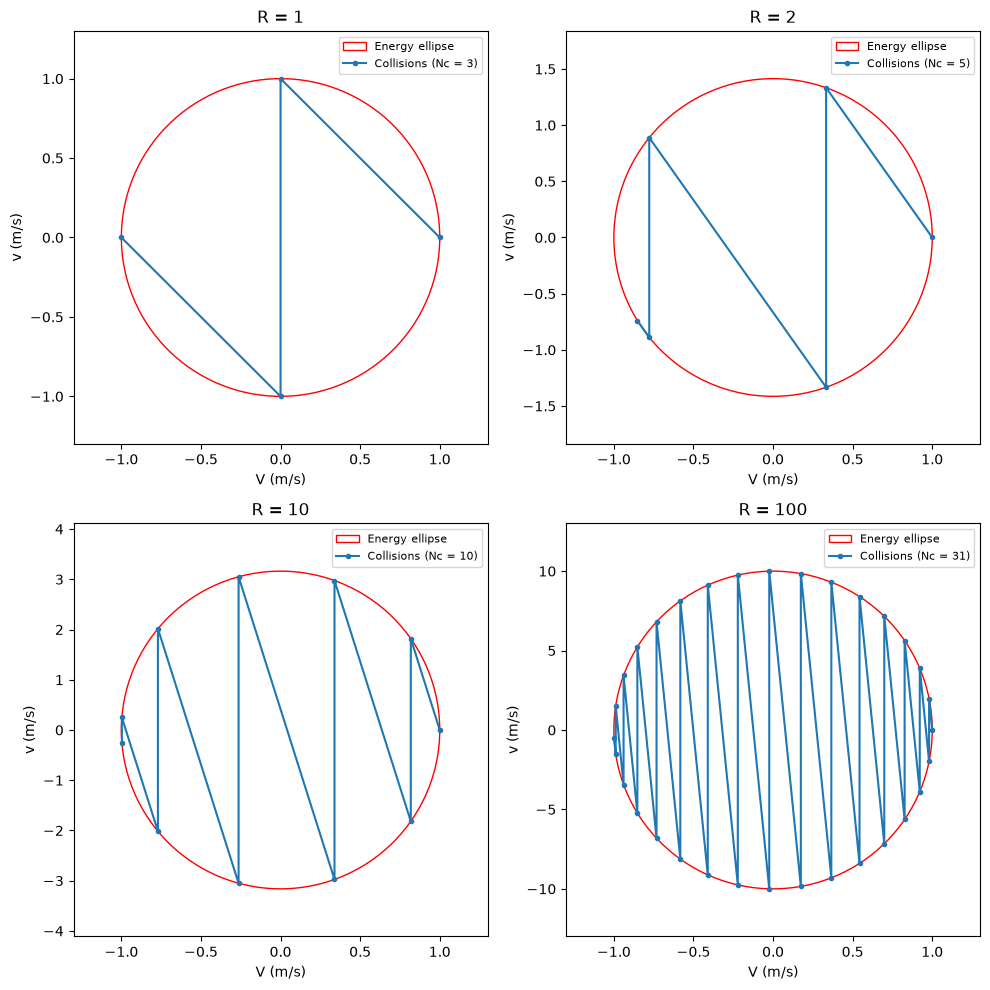

In [6]:
Vi = 1
R_values = [1, 2, 10, 100]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, R in zip(axes.flatten(), R_values):
    Nc, AllVelocities = NumberOfCollisions(Vi, R)

    #add the initial state (Vi, 0) at the beginning of the trajectory
    traj = np.array([[Vi, 0.0]] + AllVelocities)

    # semi-axes of the energy ellipse
    a = Vi
    b = Vi * np.sqrt(R)

    #plotting the ellipse as shown on tjhe statement
    ellipse = Ellipse(xy=(0, 0), width=2*a, height=2*b, fill=False,
                      color='red', label="Energy ellipse")
    ax.add_patch(ellipse)

    #trajectory of the collisions in velocity space
    ax.plot(traj[:, 0], traj[:, 1], 'o-', markersize=3,
            label=f"Collisions (Nc = {Nc})")

    #setting the limits manually
    ax.set_xlim(-1.3*a, 1.3*a)
    ax.set_ylim(-1.3*b, 1.3*b)

    ax.set_xlabel("V (m/s)")
    ax.set_ylabel("v (m/s)")
    ax.set_title(f"R = {R}")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

What changes as the mass ratio $R$ increases?

- The ellipse becomes more and more elongated along the $v$ axis, because it's semi-axis $b = V_i\sqrt{R}$ grows while $a = V_i$ stays fixed.
- The number of points on the trajectory grows, since there are more collisions ($N_c$ = 3, 5, 10, 31 for $R$ = 1, 2, 10, 100).
- All the points lie on the ellipse, which shows that kinetic energy is conserved. The vertical jumps are the wall collisions ($v \to -v$, $V$ unchanged) and the other segments are the box-box collisions.

Part 5 of 8: Number of collisions as a function of the mass ratio

Now we investigate how $N_c$ depends on the mass ratio $R$. We consider mass ratios of the form

$$ R_i = 100^i, \quad i = 1, \dots, 5 $$

We loop over $i$, compute $R_i$ and the corresponding $N_c$ with NumberOfCollisions(Vi, R), and store both in two lists, Rvalues and Nc_list. Since $N_c$ does not depend on $V_i$ (Part 3), we can use $V_i = 1$ m/s. Note that for the largest $R$ the loop has to simulate hundreds of thousands of collisions, so it can take a few seconds.

In [7]:
Vi = 1
Rvalues = []     #R_i = 100^i
Nc_list = []     #tot number of collisions for each R_i

for i in range(1, 6):
    R = 100**i
    Nc, AllVelocities = NumberOfCollisions(Vi, R)
    Rvalues.append(R)
    Nc_list.append(Nc)
    print(f"i = {i}  ->  R = {R:12}  ->  Nc = {Nc}")

i = 1  ->  R =          100  ->  Nc = 31
i = 2  ->  R =        10000  ->  Nc = 314
i = 3  ->  R =      1000000  ->  Nc = 3141
i = 4  ->  R =    100000000  ->  Nc = 31415
i = 5  ->  R =  10000000000  ->  Nc = 314159


the values of $N_c$ are 31, 314, 3141, 31415 and 314159. These are exactly the first digits of the number $\pi = 3.14159...$ Every time we multiply $R$ by 100, we get two more digits of $\pi$. So the number of collisions seems to be related to $\pi\sqrt{R}$: multiplying $R$ by 100 multiplies $\sqrt{R}$ by 10, which shifts the digits of $\pi$ by one position.

Part 6 of 8: Loglog plot of $N_c$ versus $R$

To study more systematically how $N_c$ depends on $R$, we plot the values obtained in Part 5 using logarithmic scales on both axes with plt.loglog. If $N_c$ follows a power law $N_c = A R^\alpha$, the points should lie on a straight line in this kind of plot.

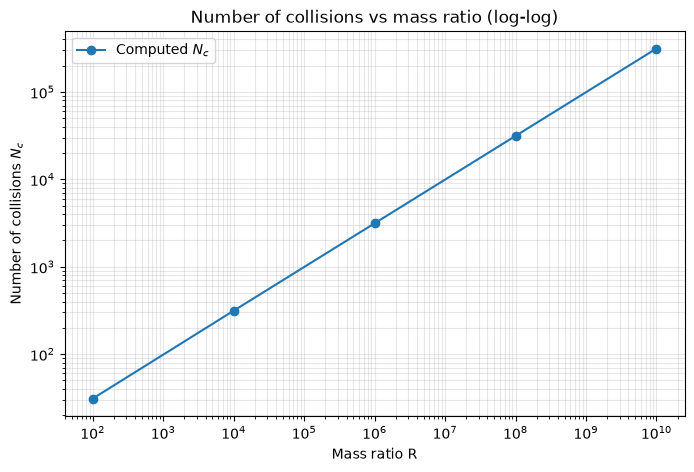

In [8]:
#plotting to check if the points goes on a straight line
plt.figure(figsize=(8, 5))

plt.loglog(Rvalues, Nc_list, 'o-', label="Computed $N_c$")

plt.xlabel("Mass ratio R")
plt.ylabel("Number of collisions $N_c$")
plt.title("Number of collisions vs mass ratio (log-log)")

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

the points lie on a straight line in the log-log plot, so $N_c$ follows a power law in $R$. The slope of the line is approximately 1/2: when $R$ increases by 8 orders of magnitude (from $10^2$ to $10^{10}$), $N_c$ increases by about 4 orders of magnitude (from 31 to 314159). This agrees with the idea that $N_c \propto \sqrt{R}$, which we will quantify with a fit in the next part.

Part 7 of 8: Fitting the power law

A power law $N_c = A R^\alpha$ becomes a straight line when we take the logarithm of both sides:

$$ \log N_c = \log A + \alpha \log R $$

we fit a straight line to the data $(\log R, \log N_c)$ with scipy.optimize.curve_fit. The parameters of the fit are $\log A$ (the intercept) and $\alpha$ (the slope). Then we recover $A = e^{\log A}$. As starting values we use $\log A = 0$ and $\alpha = 0.5$, since the log-log plot suggests a slope close to 1/2.

In [9]:
#straight line in log-log space: log(Nc) = log(A) + alpha * log(R)
def line(logR, logA, alpha):
    return logA + alpha * logR

logR = np.log(Rvalues)
logNc = np.log(Nc_list)

popt, pcov = curve_fit(line, logR, logNc, p0=[0, 0.5])
logA_opt, alpha_opt = popt
A_opt = np.exp(logA_opt)

print(f"log(A) = {logA_opt}")
print(f"A      = {A_opt}")
print(f"alpha  = {alpha_opt}")

log(A) = 1.1337796775126943
A      = 3.1073792234863356
alpha  = 0.500589152001113


The fit gives $\alpha \approx 0.5006$ and $A \approx 3.11$. The exponent is very close to $1/2$, so $N_c \propto \sqrt{R}$. The prefactor $A$ is already close to $\pi \approx 3.14$, and the small difference comes from fitting only 5 points, where the integer values of $N_c$ (digits of $\pi$ truncated) and the small-$R$ point introduce a slight deviation.

Part 8 of 8: Conjecture for the exponent and the constant

The fitted exponent $\alpha \approx 0.5006$ is very close to the simple fraction $1/2$, so we conjecture

$$ \alpha = \frac{1}{2} \quad \Rightarrow \quad N_c \propto \sqrt{R} $$

Using this value, we compute the quantity $N_c / R^{\alpha} = N_c/\sqrt{R}$ for each of the mass ratios considered in Part 5, to see if it approaches a constant as $R$ increases.

In [10]:
alpha = 0.5   #conjectured exponent

for R, Nc in zip(Rvalues, Nc_list):
    print(f"R = {R:12}  ->  Nc / R^alpha = {Nc / R**alpha:.6f}")

print(f"\npi = {np.pi:.6f}")

R =          100  ->  Nc / R^alpha = 3.100000
R =        10000  ->  Nc / R^alpha = 3.140000
R =      1000000  ->  Nc / R^alpha = 3.141000
R =    100000000  ->  Nc / R^alpha = 3.141500
R =  10000000000  ->  Nc / R^alpha = 3.141590

pi = 3.141593


Yes, $N_c/\sqrt{R}$ approaches a constant as $R$ increases: 3.1, 3.14, 3.141, 3.1415, 3.14159. This constant is $\pi \approx 3.14159$, so

$$ N_c \approx \pi \sqrt{R} = \pi \sqrt{\frac{M}{m}} $$

This explains the pattern of Task 5. Since $R_i = 100^i$, we have $\sqrt{R_i} = 10^i$, so $N_c \approx \pi \cdot 10^i$. Multiplying $\pi$ by $10^i$ shifts the decimal point $i$ places, and $N_c$ (an integer) keeps the digits before the decimal point. That is why $N_c$ gives 31, 314, 3141, 31415, 314159: the first digits of $\pi$.

The relation is an asymptotic result for large $R$, so the approximation gets better as $R$ grows. For $R = 1$ we get exactly 3 collisions, matching the first digit of $\pi$, but this is just a coincidence.